In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from scripts.utils import *

In [3]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud_df.shape

(151112, 11)

In [5]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [6]:
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [7]:
missing_values(fraud_df)

,missing_count,missing_percent
user_id,0,0.0
signup_time,0,0.0
purchase_time,0,0.0
purchase_value,0,0.0
device_id,0,0.0
source,0,0.0
browser,0,0.0
sex,0,0.0
age,0,0.0
ip_address,0,0.0


In [8]:
duplicate_count(fraud_df)

np.int64(0)

In [9]:
fraud_df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [10]:
fraud_df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

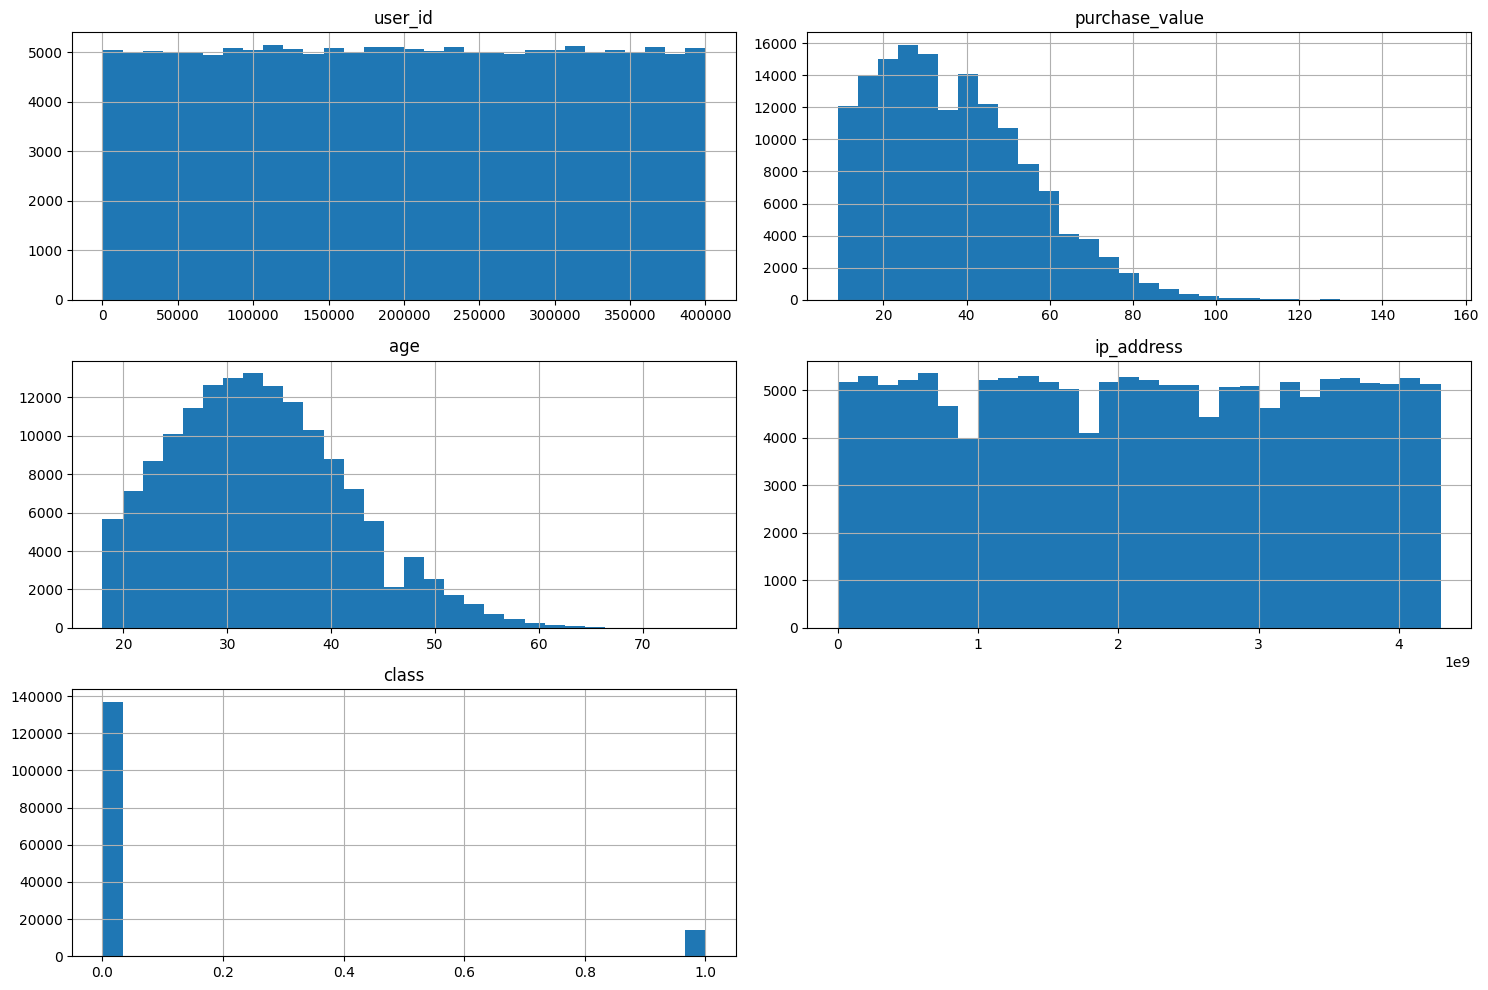

In [11]:
fraud_df.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

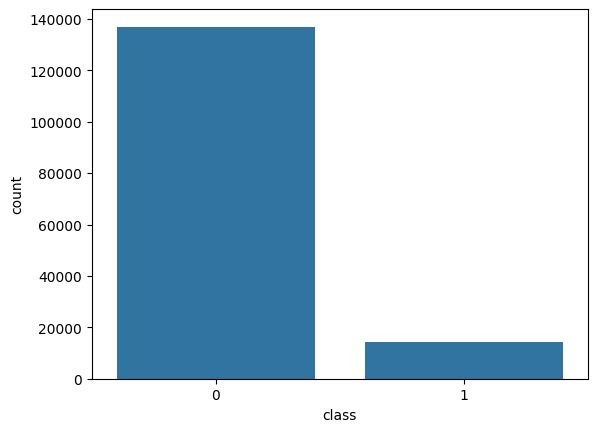

In [12]:
sns.countplot(
    data=fraud_df,
    x="class"
)

plt.show()

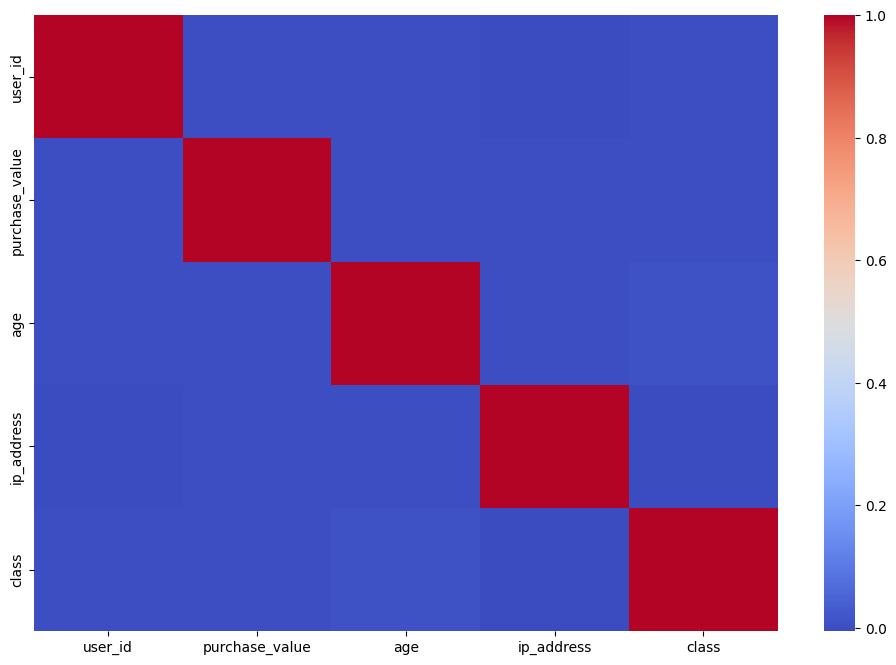

In [13]:
numeric_cols = fraud_df.select_dtypes(
    include=np.number
).columns

corr = fraud_df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

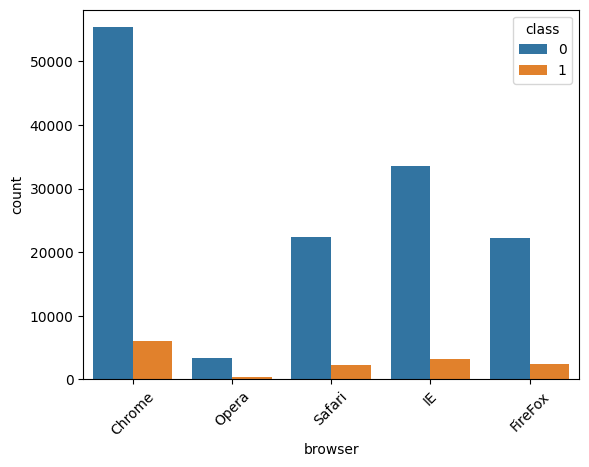

In [15]:
sns.countplot(data=fraud_df, x="browser", hue="class")
plt.xticks(rotation=45)
plt.show()

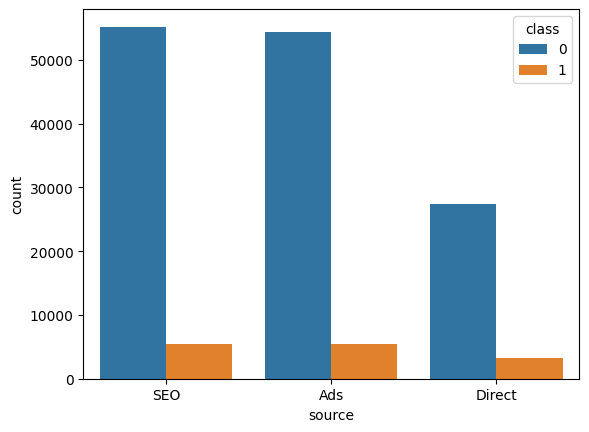

In [16]:
sns.countplot(data=fraud_df, x="source", hue="class")
plt.show()

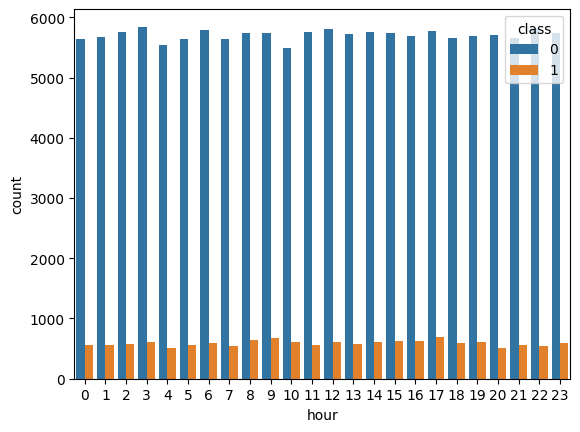

In [17]:
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

fraud_df["hour"] = fraud_df["purchase_time"].dt.hour

sns.countplot(data=fraud_df, x="hour", hue="class")
plt.show()